In [ ]:
import importlib.util, subprocess, sys

pacotes = {
    "matplotlib": "matplotlib",
    "networkx": "networkx",
    "ipywidgets": "ipywidgets",
    "dotenv": "python-dotenv",
}
faltantes = [pip_nome for modulo, pip_nome in pacotes.items() if importlib.util.find_spec(modulo) is None]
if faltantes:
    print("Instalando dependências ausentes:", ", ".join(faltantes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltantes])d


In [10]:
import os, json, re, unicodedata, random, heapq
from collections import deque, defaultdict
from itertools import product
from html import escape

PROVEDOR='offline'; MODELO_GROQ=os.getenv('GROQ_MODEL','llama-3.3-70b-versatile'); MODELO_OLLAMA=os.getenv('OLLAMA_MODEL','llama3.2')
TEMPO_TRECHO=2; TEMPO_BALDEACAO=5
LINHAS={
'Linha 1-Azul':['Tucuruvi','Parada Inglesa','Jardim São Paulo','Santana','Carandiru','Portuguesa-Tietê','Armênia','Tiradentes','Luz','São Bento','Sé','Japão-Liberdade','São Joaquim','Vergueiro','Paraíso','Ana Rosa','Vila Mariana','Santa Cruz','Praça da Árvore','Saúde','São Judas','Conceição','Jabaquara'],
'Linha 2-Verde':['Vila Madalena','Sumaré','Clínicas','Consolação','Trianon-Masp','Brigadeiro','Paraíso','Ana Rosa','Chácara Klabin','Santos-Imigrantes','Alto do Ipiranga','Sacomã','Tamanduateí','Vila Prudente'],
'Linha 3-Vermelha':['Palmeiras-Barra Funda','Marechal Deodoro','Santa Cecília','República','Anhangabaú','Sé','Pedro II','Brás','Bresser-Mooca','Belém','Tatuapé','Carrão','Penha','Vila Matilde','Guilhermina-Esperança','Patriarca-Vila Ré','Artur Alvim','Corinthians-Itaquera']}
CORES={'Linha 1-Azul':'#1e88e5','Linha 2-Verde':'#2e7d32','Linha 3-Vermelha':'#d32f2f'}
LOCAIS={'Shopping Metrô Tucuruvi':'Tucuruvi','Pinacoteca':'Luz','Catedral da Sé':'Sé','Terminal Rodoviário Jabaquara':'Jabaquara','Hospital das Clínicas':'Clínicas','MASP':'Trianon-Masp','Casa das Rosas':'Brigadeiro','Museu do Ipiranga':'Alto do Ipiranga','Memorial da América Latina':'Palmeiras-Barra Funda','Theatro Municipal':'Anhangabaú','Museu Catavento':'Pedro II','Neo Química Arena':'Corinthians-Itaquera'}
BICICLETARIOS={'Vila Madalena','Corinthians-Itaquera','Jabaquara'}

def obter_chave_groq():
    try:
        from google.colab import userdata
        return userdata.get('GROQ_API_KEY')
    except Exception: pass
    try:
        from dotenv import load_dotenv; load_dotenv()
    except Exception: pass
    return os.getenv('GROQ_API_KEY')

def chamar_llm(mensagens,modo_json=False):
    if PROVEDOR=='groq':
        from groq import Groq
        k=obter_chave_groq()
        if not k: raise RuntimeError('GROQ_API_KEY não encontrada')
        extras={'response_format':{'type':'json_object'}} if modo_json else {}
        r=Groq(api_key=k).chat.completions.create(model=MODELO_GROQ,messages=mensagens,temperature=0,**extras)
        return r.choices[0].message.content
    if PROVEDOR=='ollama':
        import ollama
        extras={'format':'json'} if modo_json else {}
        r=ollama.chat(model=MODELO_OLLAMA,messages=mensagens,options={'temperature':0},**extras)
        return r['message']['content']
    raise RuntimeError('Modo offline')

def construir_grafo_multilinhas(linhas):
    g={e:[] for es in linhas.values() for e in es}; lt=defaultdict(set)
    for l,es in linhas.items():
        for a,b in zip(es,es[1:]):
            if b not in g[a]: g[a].append(b)
            if a not in g[b]: g[b].append(a)
            lt[(a,b)].add(l); lt[(b,a)].add(l)
    return g,dict(lt)
GRAFO,LINHAS_DO_TRECHO=construir_grafo_multilinhas(LINHAS); ESTACOES=sorted(GRAFO)

def vizinhos_disponiveis(e,bloqueadas=(),linhas_paralisadas=()):
    b,p=set(bloqueadas),set(linhas_paralisadas)
    for v in GRAFO[e]:
        if v not in b and LINHAS_DO_TRECHO[(e,v)]-p: yield v

def reconstruir(pai,d):
    c=[]
    while d is not None: c.append(d); d=pai[d]
    return c[::-1]

def bfs(o,d,bloqueadas=(),linhas_paralisadas=()):
    if o not in GRAFO or d not in GRAFO: raise ValueError('Estação inexistente')
    if o in bloqueadas or d in bloqueadas:return None,[]
    q=deque([o]); pai={o:None}; vis=[]
    while q:
        a=q.popleft();vis.append(a)
        if a==d:return reconstruir(pai,d),vis
        for v in vizinhos_disponiveis(a,bloqueadas,linhas_paralisadas):
            if v not in pai:pai[v]=a;q.append(v)
    return None,vis

def dfs(o,d,bloqueadas=(),linhas_paralisadas=()):
    if o not in GRAFO or d not in GRAFO: raise ValueError('Estação inexistente')
    if o in bloqueadas or d in bloqueadas:return None,[]
    vistos=set();ordem=[]
    def rec(a,c):
        vistos.add(a);ordem.append(a)
        if a==d:return c
        for v in vizinhos_disponiveis(a,bloqueadas,linhas_paralisadas):
            if v not in vistos:
                r=rec(v,c+[v])
                if r:return r
    return rec(o,[o]),ordem

def analisar_linhas_caminho(caminho,linhas_paralisadas=()):
    if not caminho or len(caminho)<2:return {'linhas_trechos':[],'baldeacoes':[],'segmentos':[]}
    p=set(linhas_paralisadas);ops=[sorted(LINHAS_DO_TRECHO[(a,b)]-p) for a,b in zip(caminho,caminho[1:])]
    dp={l:(0,[l]) for l in ops[0]}
    for op in ops[1:]:
        nd={}
        for l in op:nd[l]=min((c+(l!=ant),seq+[l]) for ant,(c,seq) in dp.items())
        dp=nd
    _,ls=min(dp.values());trocas=[]
    for i in range(1,len(ls)):
        if ls[i]!=ls[i-1]:trocas.append((caminho[i],ls[i]))
    seg=[];ini=caminho[0];linha=ls[0]
    for i in range(1,len(ls)):
        if ls[i]!=linha:seg.append((linha,ini,caminho[i]));ini,linha=caminho[i],ls[i]
    seg.append((linha,ini,caminho[-1]))
    return {'linhas_trechos':ls,'baldeacoes':trocas,'segmentos':seg}

def busca_estado(o,d,criterio='trocas',bloqueadas=(),linhas_paralisadas=()):
    if o in bloqueadas or d in bloqueadas:return None,[]
    p=set(linhas_paralisadas);h=[((0,0),0,o,None,[o])];melhor={(o,None):(0,0)};n=0;vis=[]
    while h:
        pri,_,e,linha,c=heapq.heappop(h)
        if pri!=melhor.get((e,linha)):continue
        vis.append(e)
        if e==d:return c,vis
        for v in vizinhos_disponiveis(e,bloqueadas,p):
            for nl in sorted(LINHAS_DO_TRECHO[(e,v)]-p):
                troca=int(linha is not None and nl!=linha)
                novo=(pri[0]+(TEMPO_TRECHO+troca*TEMPO_BALDEACAO if criterio=='tempo' else troca),pri[1]+1)
                if novo<melhor.get((v,nl),(9999,9999)):
                    melhor[(v,nl)]=novo;n+=1;heapq.heappush(h,(novo,n,v,nl,c+[v]))
    return None,vis

def menos_baldeacoes(o,d,bloqueadas=(),linhas_paralisadas=()):return busca_estado(o,d,'trocas',bloqueadas,linhas_paralisadas)
def dijkstra_mais_rapida(o,d,bloqueadas=(),linhas_paralisadas=()):return busca_estado(o,d,'tempo',bloqueadas,linhas_paralisadas)
def pode_embarcar(P,Q,R):return P and ((not Q) or R)
def tabela_verdade():return [(P,Q,R,pode_embarcar(P,Q,R)) for P,Q,R in product([True,False],repeat=3)]

def fatos_base():
    f=set()
    for l,es in LINHAS.items():
        for e in es:f|={('estacao',e),('pertence',e,l)}
        for a,b in zip(es,es[1:]):f|={('trecho',a,b,l),('trecho',b,a,l)}
    f|={('proximo_de',x,e) for x,e in LOCAIS.items()};f|={('possui_bicicletario',e) for e in BICICLETARIOS}
    return f

def consultar(f,p):return [x[1:] for x in f if x[0]==p]
def r1(f):
    prox=dict(consultar(f,'proximo_de'));return {('origem',prox[l]) for (l,) in consultar(f,'usuario_esta_em') if l in prox}|{('origem',e) for (e,) in consultar(f,'usuario_esta_na_estacao')}
def r2(f):
    prox=dict(consultar(f,'proximo_de'));return {('destino',prox[l]) for (l,) in consultar(f,'usuario_quer_ir') if l in prox}|{('destino',e) for (e,) in consultar(f,'usuario_quer_ir_estacao')}
def r3(f):return {('bloqueada',e) for (e,) in consultar(f,'fechada')}
def r4(f):return {('inacessivel',e) for (e,) in consultar(f,'elevador_em_manutencao')} if consultar(f,'precisa_acessibilidade') else set()
def r5(f):
    inac={e for (e,) in consultar(f,'inacessivel')};return {('alerta',p,e) for p in ('origem','destino') for (e,) in consultar(f,p) if e in inac}
def r6(f):
    m=defaultdict(set)
    for e,l in consultar(f,'pertence'):m[e].add(l)
    return {('integracao',e) for e,ls in m.items() if len(ls)>1}
def r7(f):
    p={l for (l,) in consultar(f,'linha_paralisada')};return {('trecho_indisponivel',a,b,l) for a,b,l in consultar(f,'trecho') if l in p}
REGRAS=[('R1 origem','∀l∀e(usuario_esta_em(l) ∧ proximo_de(l,e) → origem(e))',r1),('R2 destino','∀l∀e(usuario_quer_ir(l) ∧ proximo_de(l,e) → destino(e))',r2),('R3 bloqueio','∀e(fechada(e) → bloqueada(e))',r3),('R4 acessibilidade','∀e(precisa_acessibilidade ∧ elevador_em_manutencao(e) → inacessivel(e))',r4),('R5 alerta','∀p∀e(papel(p,e) ∧ inacessivel(e) → alerta(p,e))',r5),('R6 integração','∀e∀l1∀l2(pertence(e,l1) ∧ pertence(e,l2) ∧ l1≠l2 → integracao(e))',r6),('R7 paralisação','∀l∀a∀b(linha_paralisada(l) ∧ trecho(a,b,l) → trecho_indisponivel(a,b,l))',r7)]
def encadear_para_frente(f):
    f=set(f);just={}
    while True:
        novos=set()
        for nome,formula,regra in REGRAS:
            for x in regra(f)-f:novos.add(x);just.setdefault(x,{'regra':nome,'formula':formula})
        if not novos:return f,just
        f|=novos

def planejar(pedido,fechadas=(),manutencao=(),linhas_paralisadas=(),algoritmo='BFS'):
    f=fatos_base();to,no=pedido['origem'];td,nd=pedido['destino']
    f.add(('usuario_esta_em',no) if to=='local' else ('usuario_esta_na_estacao',no));f.add(('usuario_quer_ir',nd) if td=='local' else ('usuario_quer_ir_estacao',nd))
    if pedido.get('acessibilidade'):f.add(('precisa_acessibilidade',))
    f|={('fechada',e) for e in fechadas}|{('elevador_em_manutencao',e) for e in manutencao}|{('linha_paralisada',l) for l in linhas_paralisadas}
    f,j=encadear_para_frente(f);o=consultar(f,'origem')[0][0];d=consultar(f,'destino')[0][0];b={e for (e,) in consultar(f,'bloqueada')};lp={l for (l,) in consultar(f,'linha_paralisada')}
    funcs={'BFS':bfs,'DFS':dfs,'Menos baldeações':menos_baldeacoes,'Mais rápida (Dijkstra)':dijkstra_mais_rapida};c,v=funcs[algoritmo](o,d,b,lp)
    a=analisar_linhas_caminho(c,lp) if c else {'baldeacoes':[],'segmentos':[]};par=len(c)-1 if c else None;tempo=par*TEMPO_TRECHO+len(a['baldeacoes'])*TEMPO_BALDEACAO if c else None
    return {'origem':o,'destino':d,'algoritmo':algoritmo,'caminho':c,'visitados':v,'bloqueadas':sorted(b),'linhas_paralisadas':sorted(lp),'alertas':sorted(f'{p}: {e}' for p,e in consultar(f,'alerta')),'paradas':par,'baldeacoes':a['baldeacoes'],'segmentos':a['segmentos'],'tempo_min':tempo,'regras_usadas':sorted({x['regra'] for x in j.values()}),'justificativas':j}

def normalizar(t):return ''.join(c for c in unicodedata.normalize('NFD',str(t).lower()) if unicodedata.category(c)!='Mn')
def resolver_nome(n):
    alvo=normalizar(n).strip()
    for e in ESTACOES:
        if normalizar(e)==alvo:return ('estacao',e)
    for l in LOCAIS:
        if normalizar(l)==alvo:return ('local',l)
def interpretar_offline(t):
    base=normalizar(t);ach=[]
    for n in sorted(ESTACOES+list(LOCAIS),key=len,reverse=True):
        m=re.search(r'(?<!\w)'+re.escape(normalizar(n))+r'(?!\w)',base)
        if m:ach.append((m.start(),m.end(),n))
    sel=[]
    for x in sorted(ach,key=lambda z:(z[0],-(z[1]-z[0]))):
        if not any(not(x[1]<=y[0] or x[0]>=y[1]) for y in sel):sel.append(x)
    sel.sort();ac=any(p in base for p in ['cadeira de rodas','acessibilidade','mobilidade reduzida','muleta','carrinho de bebe','elevador'])
    return {'origem':sel[0][2] if len(sel)>0 else None,'destino':sel[1][2] if len(sel)>1 else None,'acessibilidade':ac}
PROMPT_INTERPRETE='Você é o intérprete. Retorne somente JSON com origem, destino e acessibilidade. Use apenas estas estações: {e}. Locais: {l}. Nunca invente.'
def interpretar_pedido(t):
    bruto=None;fonte='offline'
    if PROVEDOR!='offline':
        try:bruto=json.loads(chamar_llm([{'role':'system','content':PROMPT_INTERPRETE.format(e=', '.join(ESTACOES),l=', '.join(LOCAIS))},{'role':'user','content':t}],True));fonte=PROVEDOR
        except Exception:pass
    bruto=bruto or interpretar_offline(t);o,d=resolver_nome(bruto.get('origem')),resolver_nome(bruto.get('destino'))
    return ({'origem':o,'destino':d,'acessibilidade':bool(bruto.get('acessibilidade'))},f'Interpretado via {fonte}') if o and d else (None,f'Não entendi: {bruto}')
def narrar_offline(r):
    if not r['caminho']:return f"Não há rota de {r['origem']} até {r['destino']}."
    s=f"Embarque em {r['origem']} e siga até {r['destino']}: {r['paradas']} paradas, cerca de {r['tempo_min']} minutos."
    if r['baldeacoes']:s+=' Baldeações: '+'; '.join(f'em {e}, troque para {l}' for e,l in r['baldeacoes'])+'.'
    if r['alertas']:s+=' Atenção: '+'; '.join(r['alertas'])+'.'
    return s
def narrar(r):return narrar_offline(r)

def desenhar_rede_html(r):
    c,v,b=set(r.get('caminho') or []),set(r.get('visitados') or []),set(r.get('bloqueadas') or []);out=['<div>']
    for l,es in LINHAS.items():
        out.append(f"<h4 style='color:{CORES[l]}'>{escape(l)}</h4><div>")
        for e in es:
            bg='#ffcdd2' if e in b else CORES[l] if e in c else '#eee' if e in v else 'white';fg='white' if e in c else '#333'
            out.append(f"<span style='display:inline-block;padding:4px;margin:2px;border:1px solid #999;border-radius:12px;background:{bg};color:{fg}'>{escape(e)}</span>")
        out.append('</div>')
    return ''.join(out)+'</div>'

def criar_painel():
    import ipywidgets as w
    from IPython.display import display,HTML,clear_output
    ops=[(f'Local: {l}',('local',l)) for l in sorted(LOCAIS)]+[(f'Estação: {e}',('estacao',e)) for e in ESTACOES]
    txt=w.Textarea(placeholder='Catedral da Sé para MASP');o=w.Dropdown(options=ops,value=('estacao','Tucuruvi'),description='Origem');d=w.Dropdown(options=ops,value=('estacao','Corinthians-Itaquera'),description='Destino');ac=w.Checkbox(description='Acessibilidade');fe=w.SelectMultiple(options=ESTACOES,description='Fechadas');ma=w.SelectMultiple(options=ESTACOES,description='Elevadores');lp=w.SelectMultiple(options=list(LINHAS),description='Linhas off');alg=w.RadioButtons(options=['BFS','DFS','Menos baldeações','Mais rápida (Dijkstra)'],description='Busca');bi=w.Button(description='Interpretar',button_style='info');bb=w.Button(description='Buscar rota',button_style='success');saida=w.Output()
    def interp(_):
        with saida:
            clear_output();p,msg=interpretar_pedido(txt.value);print(msg)
            if p:o.value=p['origem'];d.value=p['destino'];ac.value=p['acessibilidade']
    def buscar(_):
        with saida:
            clear_output();r=planejar({'origem':o.value,'destino':d.value,'acessibilidade':ac.value},fe.value,ma.value,lp.value,alg.value);print(narrar(r));print('Visitadas:',len(r['visitados']),'Regras:',r['regras_usadas']);display(HTML(desenhar_rede_html(r)))
    bi.on_click(interp);bb.on_click(buscar);painel=w.VBox([w.HTML('<h2>MetrôBot SP 2.0</h2>'),txt,bi,w.HBox([o,d]),w.HBox([ac,alg]),w.HBox([fe,ma,lp]),bb,saida]);display(painel);return painel

def plotar_mapa_networkx(resultado=None):
    import networkx as nx, matplotlib.pyplot as plt
    G=nx.Graph()
    for l,es in LINHAS.items():
        for a,b in zip(es,es[1:]):G.add_edge(a,b,linha=l)
    pos=nx.spring_layout(G,seed=42);rota=set((resultado or {}).get('caminho') or []);cores=['#ffca28' if n in rota else '#ddd' for n in G]
    plt.figure(figsize=(18,12));nx.draw(G,pos,with_labels=True,node_color=cores,node_size=250,font_size=6);plt.show()

def relatorio_esforco(n=10,semente=42,mostrar_grafico=True):
    rng=random.Random(semente);pares=[tuple(rng.sample(ESTACOES,2)) for _ in range(n)];dados=[]
    for a,b in pares:
        cb,vb=bfs(a,b);cd,vd=dfs(a,b);dados.append((f'{a} → {b}',len(vb),len(vd)))
    if mostrar_grafico:
        try:
            import matplotlib.pyplot as plt
            x=range(n);plt.figure(figsize=(12,5));plt.bar([i-.2 for i in x],[d[1] for d in dados],.4,label='BFS');plt.bar([i+.2 for i in x],[d[2] for d in dados],.4,label='DFS');plt.legend();plt.title('Esforço BFS x DFS');plt.xlabel('Viagem');plt.ylabel('Estações visitadas');plt.show()
        except ModuleNotFoundError:
            print('Matplotlib não está instalado. O relatório textual será exibido sem gráfico.')
    for i,(viagem,bfs_vis,dfs_vis) in enumerate(dados,1):
        print(f'{i:02d}. {viagem} | BFS: {bfs_vis} | DFS: {dfs_vis}')
    return dados

def rodar_testes():
    assert len(GRAFO)==52 and LINHAS_DO_TRECHO[('Paraíso','Ana Rosa')]=={'Linha 1-Azul','Linha 2-Verde'}
    f,_=encadear_para_frente(fatos_base());assert {e for (e,) in consultar(f,'integracao')}=={'Sé','Paraíso','Ana Rosa'}
    c,_=bfs('Tucuruvi','Corinthians-Itaquera');a=analisar_linhas_caminho(c);assert len(c)-1==22 and len(a['baldeacoes'])==1 and a['baldeacoes'][0][0]=='Sé'
    c,_=bfs('Vila Madalena','Jabaquara');a=analisar_linhas_caminho(c);assert len(c)-1==14 and len(a['baldeacoes'])==1
    c,_=bfs('Palmeiras-Barra Funda','Vila Prudente');a=analisar_linhas_caminho(c);assert len(c)-1==16 and len(a['baldeacoes'])==2
    assert bfs('Tucuruvi','Brás',{'Sé'})[0] is None
    assert bfs('Vila Madalena','Jabaquara',{'Paraíso'})[0] is None
    c,_=bfs('Vila Prudente','Jabaquara',{'Paraíso'});assert len(c)-1==13 and 'Ana Rosa' in c
    r=planejar({'origem':('local','Catedral da Sé'),'destino':('local','Pinacoteca'),'acessibilidade':True},manutencao=['Luz']);assert 'destino: Luz' in r['alertas']
    r=planejar({'origem':('estacao','Sé'),'destino':('estacao','Tiradentes'),'acessibilidade':True},manutencao=['Luz']);assert r['alertas']==[] and 'Luz' in r['caminho']
    f,_=encadear_para_frente(fatos_base()|{('linha_paralisada','Linha 3-Vermelha')});assert ('trecho_indisponivel','Sé','Pedro II','Linha 3-Vermelha') in f
    assert resolver_nome('se')==('estacao','Sé') and resolver_nome('Avenida Paulista') is None
    p,_=interpretar_pedido('Catedral da Sé para MASP');assert p['origem']==('local','Catedral da Sé') and p['destino']==('local','MASP')
    assert menos_baldeacoes('Palmeiras-Barra Funda','Vila Prudente')[0]
    assert dijkstra_mais_rapida('Tucuruvi','Corinthians-Itaquera')[0]
    print('Todos os 19 testes passaram!')


In [11]:
rodar_testes()
print(tabela_verdade())

Todos os 19 testes passaram!
[(True, True, True, True), (True, True, False, False), (True, False, True, True), (True, False, False, True), (False, True, True, False), (False, True, False, False), (False, False, True, False), (False, False, False, False)]


In [12]:
painel = criar_painel()


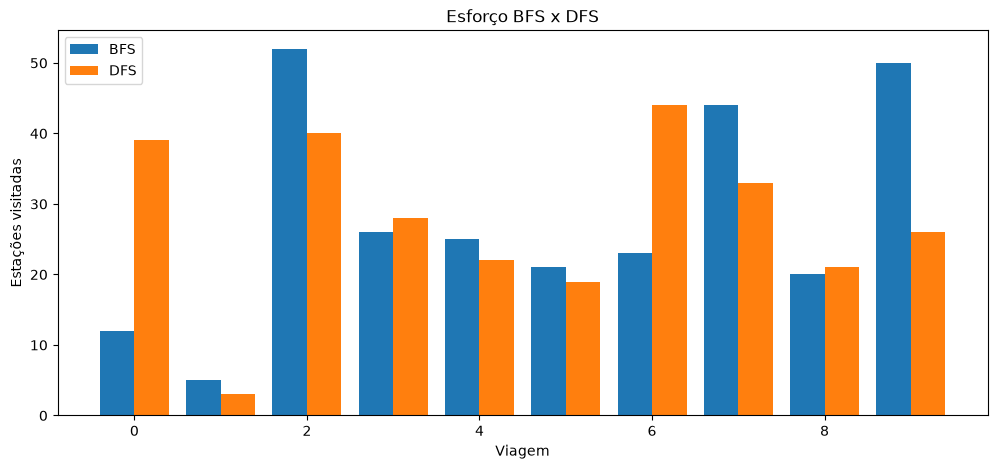

01. São Judas → Brigadeiro | BFS: 12 | DFS: 39
02. Ana Rosa → Vergueiro | BFS: 5 | DFS: 3
03. Jabaquara → Corinthians-Itaquera | BFS: 52 | DFS: 40
04. Consolação → Brás | BFS: 26 | DFS: 28
05. Vergueiro → Bresser-Mooca | BFS: 25 | DFS: 22
06. Tatuapé → Vergueiro | BFS: 21 | DFS: 19
07. Santana → Belém | BFS: 23 | DFS: 44
08. Sumaré → Penha | BFS: 44 | DFS: 33
09. Anhangabaú → Ana Rosa | BFS: 20 | DFS: 21
10. Belém → Conceição | BFS: 50 | DFS: 26


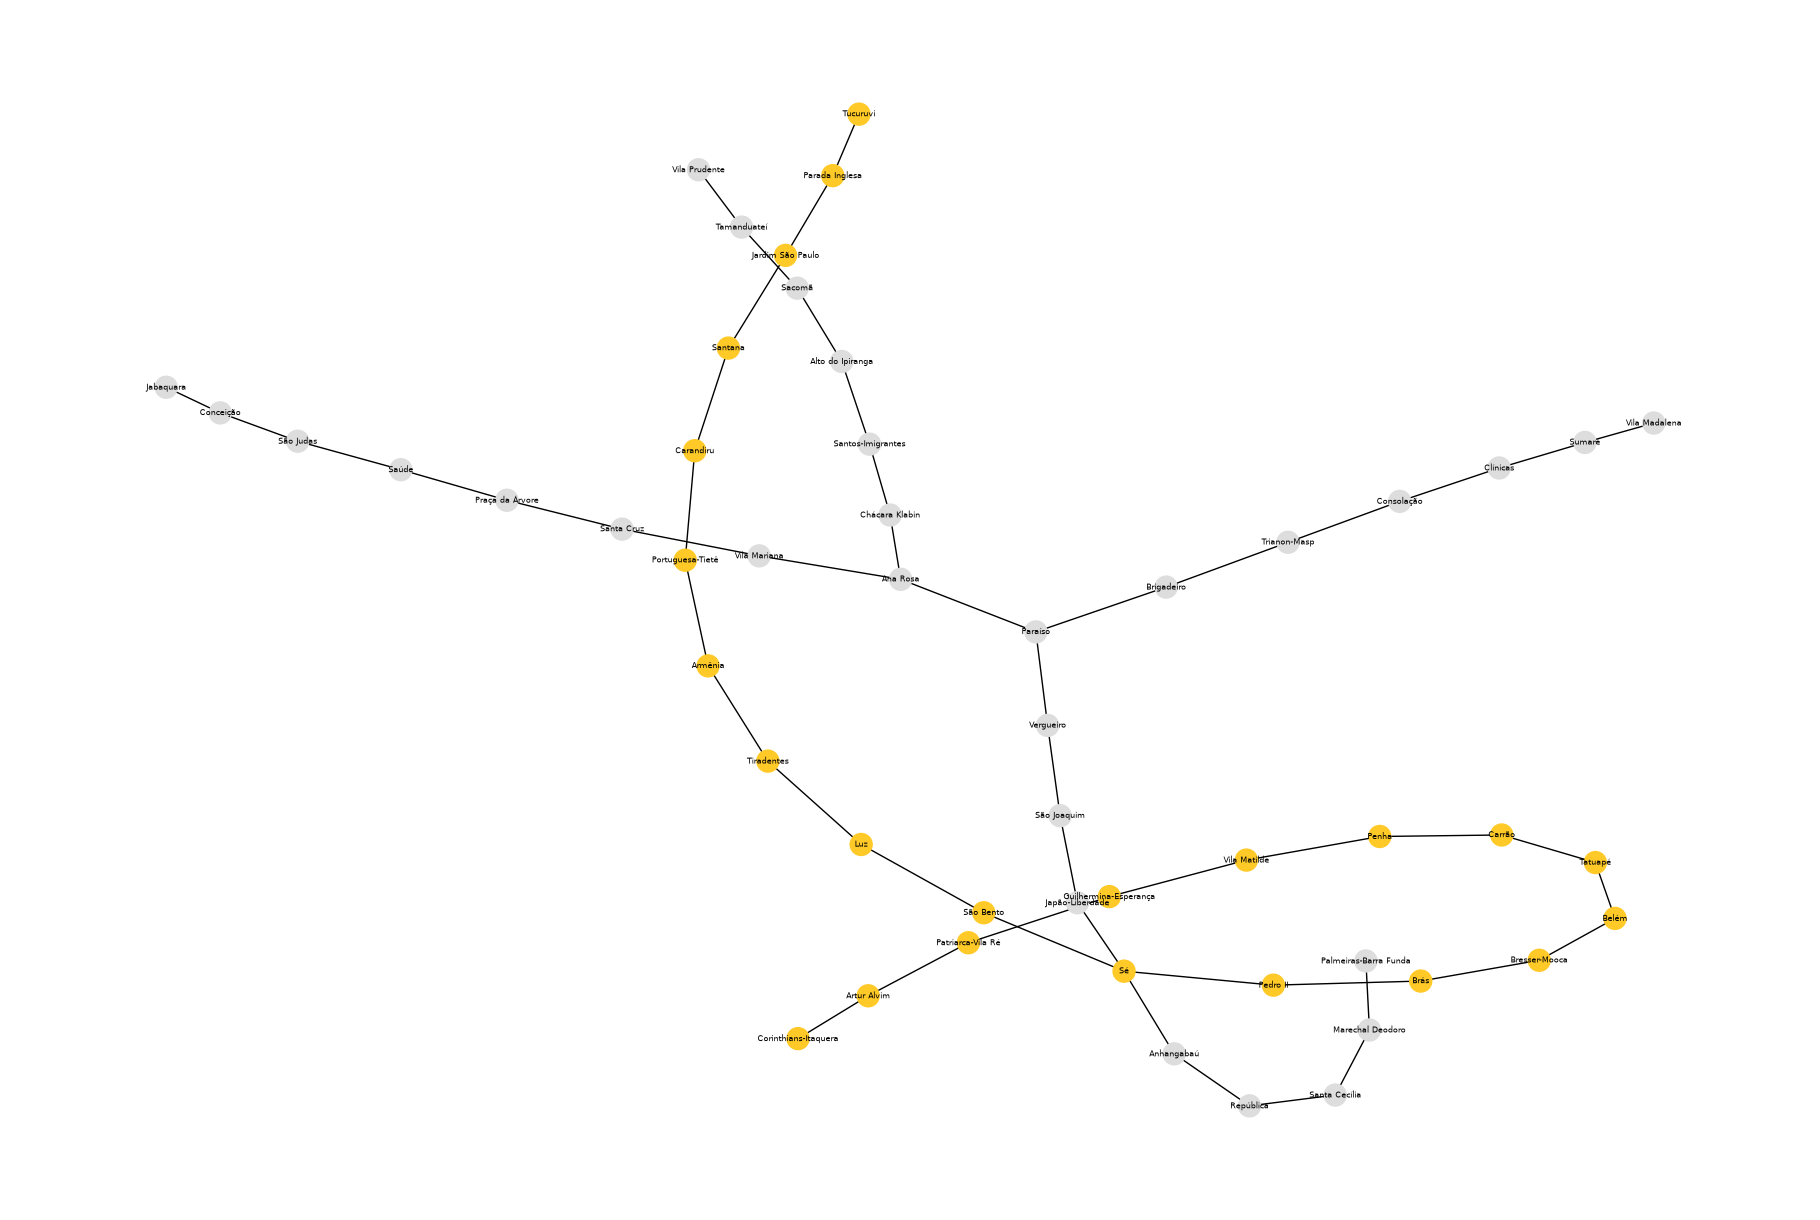

In [13]:
relatorio_esforco()
plotar_mapa_networkx(planejar({"origem":("estacao","Tucuruvi"),"destino":("estacao","Corinthians-Itaquera"),"acessibilidade":False}))
